TUGAS FISIKA KOMPUTASI LANJUT 11 SIMULASI GELOMBANG\
Ardiansah Nur Rohman\
230322607922

Tugas 1

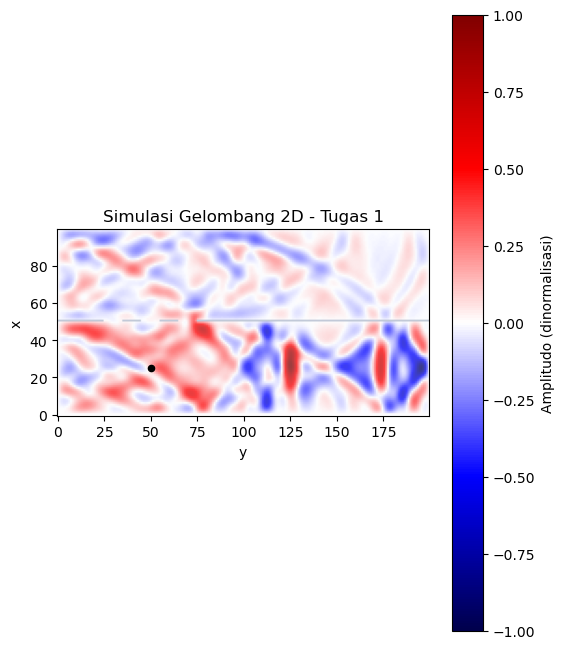

In [2]:
# tugas1_wave2d.py
# Simulasi gelombang 2D untuk Tugas 1
# Domain: 100 x 200, tiga celah lebar 10 di x=50 (y=30,50,70), sumber di (25,50), c=1
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ---------------- Parameter domain & simulasi ----------------
nx, ny = 100, 200       # grid: x dim = 100, y dim = 200
dx = dy = 1.0
c = 1.0
dt = 0.45               # pilih s.t. CFL terpenuhi: c*dt/dx < 1/sqrt(2) (~0.707)
steps = 400             # jumlah langkah waktu

# cek stabilitas (CFL)
assert c * dt / dx < 1 / np.sqrt(2), "CFL condition tidak terpenuhi!"

# ---------------- Inisialisasi array ----------------
u = np.zeros((nx, ny))        # kondisi sekarang
u_prev = np.zeros((nx, ny))   # kondisi sebelumnya
u_next = np.zeros((nx, ny))   # kondisi berikutnya

# ---------------- Sumber Gaussian di (25,50) ----------------
x0, y0 = 25, 50   # indeks sumber (i, j) => (x, y)
sigma = 3.0
X = np.arange(nx)[:, None]
Y = np.arange(ny)[None, :]
gaussian = np.exp(-(((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2)))
# gunakan gaussian sebagai kondisi awal (bisa diberi tanda - jika mau)
u = gaussian.copy()
u_prev = gaussian.copy()

# ---------------- Mask penghalang dengan 3 celah ----------------
mask = np.ones((nx, ny), dtype=bool)  # True = ruang terbuka (gelombang boleh lewat)
barrier_x = 50                         # kolom penghalang (x-index)
gap_centers = [30, 50, 70]             # posisi pusat celah (y-index)
gap_width = 10                         # lebar celah (unit grid)

# set seluruh baris barrier_x menjadi tembok
mask[barrier_x, :] = False
for yc in gap_centers:
    start = int(yc - gap_width // 2)
    end = int(yc + gap_width // 2)
    start = max(0, start)
    end = min(ny, end)
    mask[barrier_x, start:end] = True  # buka celah

# overlay untuk visualisasi penghalang (opsional)
overlay = np.zeros((nx, ny))
overlay[barrier_x, :] = 1.0
for yc in gap_centers:
    start = int(yc - gap_width // 2)
    end = int(yc + gap_width // 2)
    overlay[barrier_x, start:end] = 0.0

# ---------------- Fungsi update (explicit scheme) ----------------
def step_time():
    global u, u_prev, u_next
    # update interior (hindari tepi)
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            # jika titik bagian dari penghalang (mask False) => tetap 0
            if not mask[i, j]:
                u_next[i, j] = 0.0
                continue
            lap = (u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1] - 4 * u[i, j]) / dx**2
            u_next[i, j] = 2 * u[i, j] - u_prev[i, j] + (c * dt)**2 * lap

    # kondisi batas Dirichlet: tepi = 0
    u_next[0, :] = 0.0
    u_next[-1, :] = 0.0
    u_next[:, 0] = 0.0
    u_next[:, -1] = 0.0

    # shift waktu
    u_prev, u = u, u_next.copy()

# ---------------- Visualisasi animasi ----------------
fig, ax = plt.subplots(figsize=(6, 8))
im_wave = ax.imshow(u, cmap='seismic', vmin=-1, vmax=1, origin='lower')
im_barrier = ax.imshow(overlay, cmap='Blues', alpha=0.25, origin='lower')
ax.scatter(y0, x0, color='k', s=20)  # titik sumber (tanda)
ax.set_title('Simulasi Gelombang 2D - Tugas 1')
ax.set_xlabel('y')
ax.set_ylabel('x')
cbar = fig.colorbar(im_wave, ax=ax)
cbar.set_label('Amplitudo (dinormalisasi)')

def update(frame):
    # lakukan 1 langkah waktu
    step_time()
    # normalisasi untuk visualisasi (hindari pembesaran numerik)
    maxv = np.max(np.abs(u))
    if maxv == 0:
        display = u
    else:
        display = u / maxv
    im_wave.set_array(display)
    # barrier overlay tetap
    im_barrier.set_array(overlay)
    return [im_wave, im_barrier]

ani = animation.FuncAnimation(fig, update, frames=steps, interval=30, blit=True)

# Simpan animasi jika mau (opsional - butuh ffmpeg)
ani.save("tugas1_simulasi.mp4", writer='ffmpeg', fps=30)

plt.show()


TUGAS 2

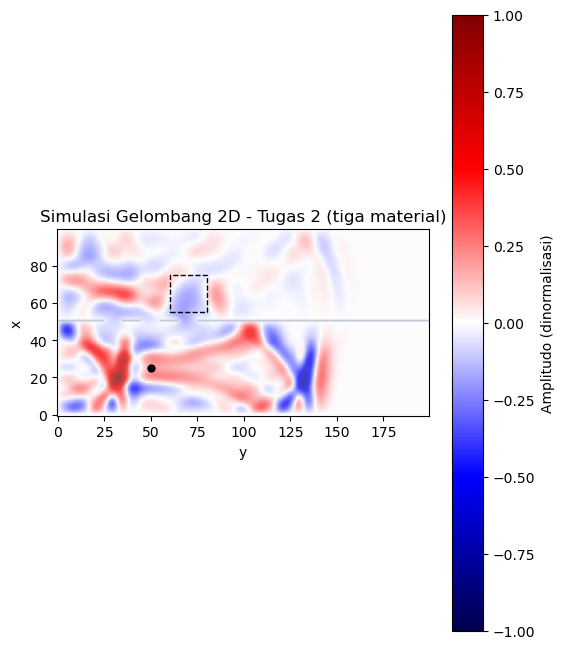

In [4]:
# tugas2_wave2d.py
# Simulasi gelombang 2D Tugas 2
# Domain: 100 x 200, tiga celah di x=50 (y=30,50,70), sumber di (25,50)
# Tiga material: c = 0.75 (atas), c = 1.0 (bawah), c = 2.0 (inclusion kanan atas)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ---------------- Parameter domain & simulasi ----------------
nx, ny = 100, 200       # grid: x dim = 100, y dim = 200
dx = dy = 1.0
dt = 0.3               # pilih s.t. CFL terpenuhi: c_max*dt/dx < 1/sqrt(2)
steps = 400             # jumlah langkah waktu

# Kecepatan maksimum yang akan muncul di peta c (untuk cek CFL)
c_max = 2.0
assert c_max * dt / dx < 1 / np.sqrt(2), "CFL condition tidak terpenuhi untuk c_max!"

# ---------------- Inisialisasi array ----------------
u = np.zeros((nx, ny))        # kondisi sekarang
u_prev = np.zeros((nx, ny))   # kondisi sebelumnya
u_next = np.zeros((nx, ny))   # kondisi berikutnya

# ---------------- Sumber Gaussian di (25,50) ----------------
x0, y0 = 25, 50   # indeks sumber (i, j) => (x, y)
sigma = 3.0
X = np.arange(nx)[:, None]
Y = np.arange(ny)[None, :]
gaussian = np.exp(-(((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2)))
# gunakan gaussian sebagai kondisi awal (bisa diberi tanda - jika mau)
u = gaussian.copy()
u_prev = gaussian.copy()

# ---------------- Mask penghalang dengan 3 celah (sama seperti Tugas 1) ----------------
mask = np.ones((nx, ny), dtype=bool)  # True = ruang terbuka (gelombang boleh lewat)
barrier_x = 50                         # kolom penghalang (x-index)
gap_centers = [30, 50, 70]             # posisi pusat celah (y-index)
gap_width = 10                         # lebar celah (unit grid)

# set seluruh baris barrier_x menjadi tembok
mask[barrier_x, :] = False
for yc in gap_centers:
    start = int(yc - gap_width // 2)
    end = int(yc + gap_width // 2)
    start = max(0, start)
    end = min(ny, end)
    mask[barrier_x, start:end] = True  # buka celah

# overlay untuk visualisasi penghalang (opsional)
overlay = np.zeros((nx, ny))
overlay[barrier_x, :] = 1.0
for yc in gap_centers:
    start = int(yc - gap_width // 2)
    end = int(yc + gap_width // 2)
    overlay[barrier_x, start:end] = 0.0

# ---------------- Peta kecepatan (c_map) ----------------
# Default c = 0.75 (atas), lalu bagian bawah c = 1.0, plus kotak kecil c = 2.0 di kanan atas
c_map = np.ones((nx, ny)) * 0.75  # mulai dengan 0.75 di seluruh domain

# bagian bawah (misalnya x indices 40..99) jadi c = 1.0
c_map[40: , :] = 1.0

# inclusion (kotak) di kanan atas: y in [60,80), x in [55,75)
inc_x_start, inc_x_end = 55, 75
inc_y_start, inc_y_end = 60, 80
c_map[inc_x_start:inc_x_end, inc_y_start:inc_y_end] = 2.0

# -- Opsional: set nilai c di lokasi penghalang ke 0 agar penghalang benar-benar 'solid' --
# Jika penghalang seharusnya mencegah gelombang lewat (bukan hanya nilai c berbeda),
# kita tetap menggunakan mask untuk memblokir update. Jadi tidak perlu set c_map di barrier.

# ---------------- Fungsi update (explicit scheme, c lokal) ----------------
def step_time():
    global u, u_prev, u_next
    # update interior (hindari tepi)
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            # jika titik bagian dari penghalang (mask False) => tetap 0
            if not mask[i, j]:
                u_next[i, j] = 0.0
                continue
            lap = (u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1] - 4 * u[i, j]) / dx**2
            # gunakan c lokal pada titik (i,j)
            cc = c_map[i, j]
            u_next[i, j] = 2 * u[i, j] - u_prev[i, j] + (cc * dt)**2 * lap

    # kondisi batas Dirichlet: tepi = 0
    u_next[0, :] = 0.0
    u_next[-1, :] = 0.0
    u_next[:, 0] = 0.0
    u_next[:, -1] = 0.0

    # shift waktu
    u_prev, u = u, u_next.copy()

# ---------------- Visualisasi animasi ----------------
fig, ax = plt.subplots(figsize=(6, 8))
im_wave = ax.imshow(u, cmap='seismic', vmin=-1, vmax=1, origin='lower')
# show overlay barrier semi-transparent
im_barrier = ax.imshow(overlay, cmap='Blues', alpha=0.25, origin='lower')
ax.scatter(y0, x0, color='k', s=25)  # titik sumber (tanda)
ax.set_title('Simulasi Gelombang 2D - Tugas 2 (tiga material)')
ax.set_xlabel('y')
ax.set_ylabel('x')
cbar = fig.colorbar(im_wave, ax=ax)
cbar.set_label('Amplitudo (dinormalisasi)')

# optional: show rectangle of inclusion on the plot (for visual guidance)
rect_x = [inc_y_start, inc_y_end, inc_y_end, inc_y_start, inc_y_start]  # y coords
rect_y = [inc_x_start, inc_x_start, inc_x_end, inc_x_end, inc_x_start]  # x coords
ax.plot(rect_x, rect_y, linestyle='--', color='k', linewidth=1)

def update(frame):
    step_time()
    # normalisasi untuk visualisasi
    maxv = np.max(np.abs(u))
    if maxv == 0:
        display = u
    else:
        display = u / maxv
    im_wave.set_array(display)
    im_barrier.set_array(overlay)
    return [im_wave, im_barrier]

ani = animation.FuncAnimation(fig, update, frames=steps, interval=30, blit=True)

# Simpan animasi jika mau (opsional - butuh ffmpeg)
ani.save("tugas2_simulasi.mp4", writer='ffmpeg', fps=30)

plt.show()
